In [32]:
import pandas as pd

import scipy.stats as stats
import statsmodels.api as sm

import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='darkgrid')

In [33]:
car_data = pd.read_csv(r"C:\dataset\CarPrice_Assignment.csv")

car_data.head()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


Text(0.5, 1.0, 'Curbweight vs Price')

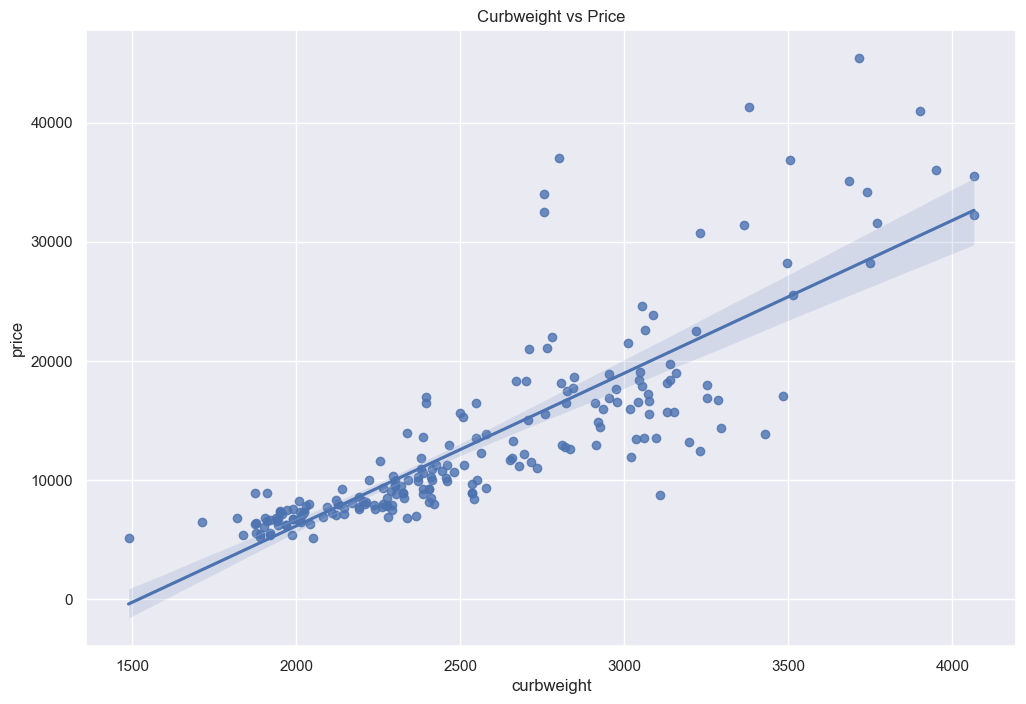

In [34]:
plt.figure(figsize=(12, 8))

sns.regplot(data=car_data, x='curbweight', y='price')

plt.title('Curbweight vs Price')

Text(0.5, 1.0, 'Car Body vs Price')

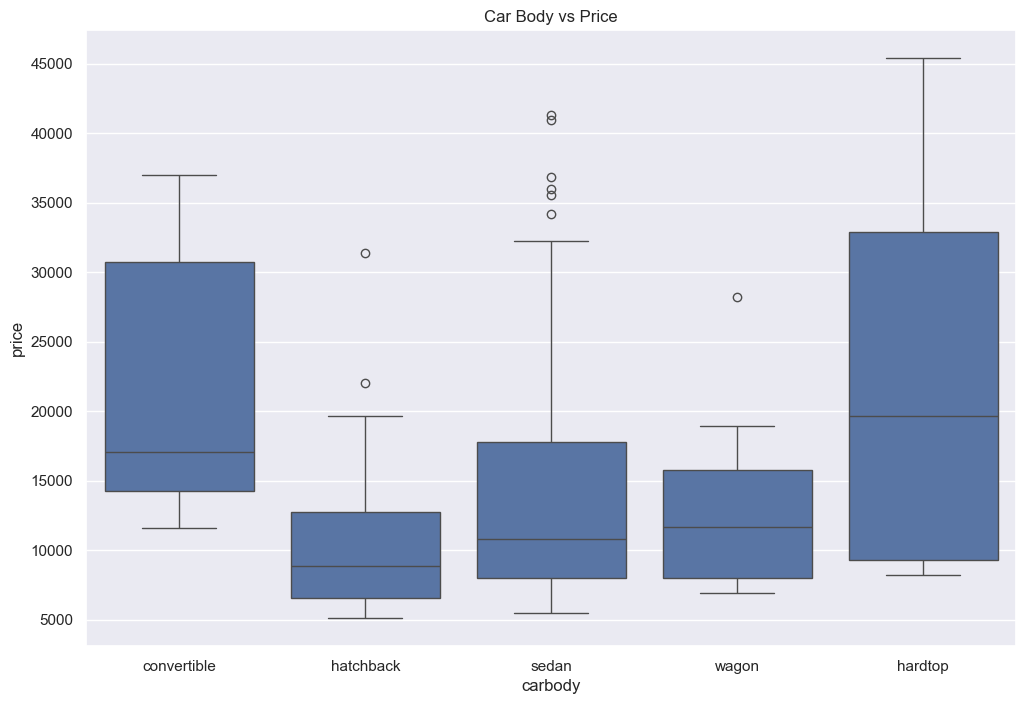

In [35]:
plt.figure(figsize=(12, 8))

sns.boxplot(data=car_data, x='carbody', y='price')

plt.title('Car Body vs Price')

In [36]:
data_corr = car_data[['enginesize', 'boreratio', 'compressionratio', 'peakrpm', 'citympg', 'highwaympg', 'price']].corr()

data_corr

,enginesize,boreratio,compressionratio,peakrpm,citympg,highwaympg,price
enginesize,1.000000,0.583774,0.028971,-0.244660,-0.653658,-0.677470,0.874145
boreratio,0.583774,1.000000,0.005197,-0.254976,-0.584532,-0.587012,0.553173
compressionratio,0.028971,0.005197,1.000000,-0.435741,0.324701,0.265201,0.067984
peakrpm,-0.244660,-0.254976,-0.435741,1.000000,-0.113544,-0.054275,-0.085267
citympg,-0.653658,-0.584532,0.324701,-0.113544,1.000000,0.971337,-0.685751
highwaympg,-0.677470,-0.587012,0.265201,-0.054275,0.971337,1.000000,-0.697599
price,0.874145,0.553173,0.067984,-0.085267,-0.685751,-0.697599,1.000000


Text(0.5, 1.0, 'Correlations')

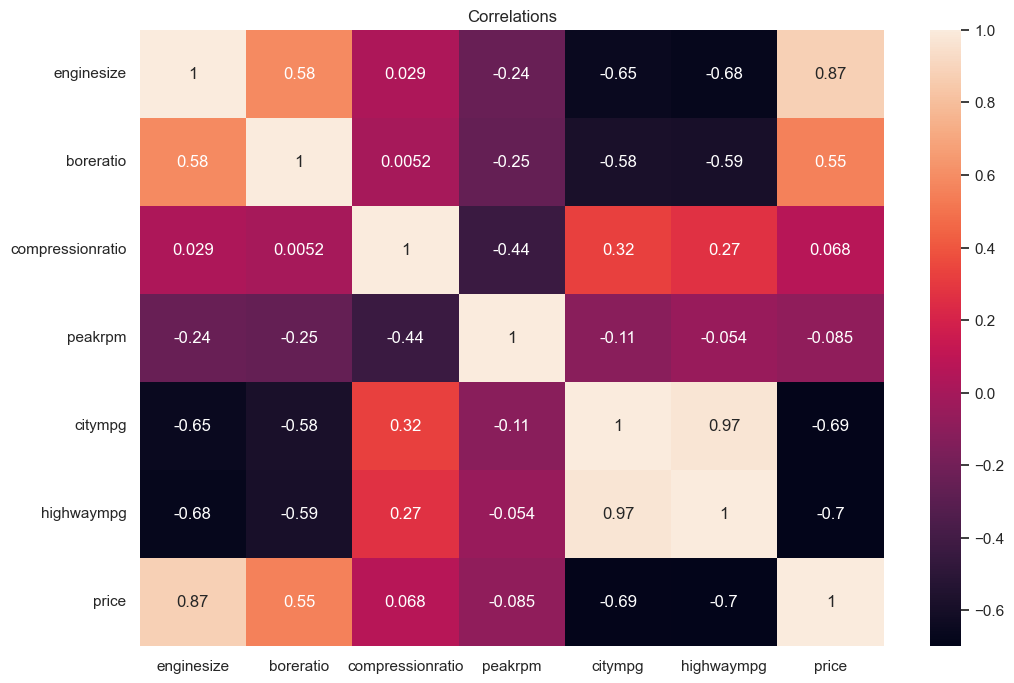

In [37]:
plt.figure(figsize=(12, 8))

sns.heatmap(data=data_corr, annot=True)

plt.title('Correlations')

In [38]:
cols = ['aspiration', 'doornumber', 'enginelocation', 'fueltype']

car_data[cols].sample(10)

,aspiration,doornumber,enginelocation,fueltype
79,turbo,two,front,gas
158,std,four,front,diesel
123,std,four,front,gas
26,std,four,front,gas
83,turbo,two,front,gas
172,std,two,front,gas
191,std,four,front,gas
97,std,four,front,gas
152,std,four,front,gas
59,std,two,front,gas


In [39]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in cols:
    car_data[col] = le.fit_transform(car_data[col])

In [40]:
car_data[cols].sample(10)

,aspiration,doornumber,enginelocation,fueltype
134,0,1,0,1
86,0,0,0,1
138,0,1,0,1
168,0,1,0,1
159,0,0,0,0
78,0,1,0,1
64,0,0,0,1
91,0,1,0,1
141,0,0,0,1
82,1,1,0,1


In [41]:
car_data = car_data.drop(columns=['CarName', 'car_ID'])

car_data.head()

,symboling,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,carlength,carwidth,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,3,1,0,1,convertible,rwd,0,88.6,168.8,64.1,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,3,1,0,1,convertible,rwd,0,88.6,168.8,64.1,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,1,1,0,1,hatchback,rwd,0,94.5,171.2,65.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,2,1,0,0,sedan,fwd,0,99.8,176.6,66.2,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,2,1,0,0,sedan,4wd,0,99.4,176.6,66.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [42]:
cat_columns = ['carbody', 'enginetype', 'drivewheel', 'cylindernumber', 'fuelsystem']

car_data = pd.get_dummies(
    car_data,
    columns=cat_columns,
    drop_first=True,
    dtype=int
)

In [43]:
car_data.head()

,symboling,fueltype,aspiration,doornumber,enginelocation,wheelbase,carlength,carwidth,carheight,curbweight,...,cylindernumber_three,cylindernumber_twelve,cylindernumber_two,fuelsystem_2bbl,fuelsystem_4bbl,fuelsystem_idi,fuelsystem_mfi,fuelsystem_mpfi,fuelsystem_spdi,fuelsystem_spfi
0,3,1,0,1,0,88.6,168.8,64.1,48.8,2548,...,0,0,0,0,0,0,0,1,0,0
1,3,1,0,1,0,88.6,168.8,64.1,48.8,2548,...,0,0,0,0,0,0,0,1,0,0
2,1,1,0,1,0,94.5,171.2,65.5,52.4,2823,...,0,0,0,0,0,0,0,1,0,0
3,2,1,0,0,0,99.8,176.6,66.2,54.3,2337,...,0,0,0,0,0,0,0,1,0,0
4,2,1,0,0,0,99.4,176.6,66.4,54.3,2824,...,0,0,0,0,0,0,0,1,0,0


In [44]:
car_data = car_data.sample(frac=1).reset_index(drop=True)

In [45]:
x = car_data.drop(['price'], axis=1)

y = car_data['price']

In [47]:
x = sm.add_constant(x)

x.head()

,const,symboling,fueltype,aspiration,doornumber,enginelocation,wheelbase,carlength,carwidth,carheight,...,cylindernumber_three,cylindernumber_twelve,cylindernumber_two,fuelsystem_2bbl,fuelsystem_4bbl,fuelsystem_idi,fuelsystem_mfi,fuelsystem_mpfi,fuelsystem_spdi,fuelsystem_spfi
0,1.0,3,1,0,1,1,89.5,168.9,65.0,51.6,...,0,0,0,0,0,0,0,1,0,0
1,1.0,1,1,0,1,0,94.5,165.6,63.8,53.3,...,0,0,0,1,0,0,0,0,0,0
2,1.0,0,1,0,0,0,100.4,184.6,66.5,56.1,...,0,0,0,0,0,0,0,1,0,0
3,1.0,1,1,0,1,0,94.5,155.9,63.6,52.0,...,0,0,0,1,0,0,0,0,0,0
4,1.0,2,1,0,0,0,99.8,176.6,66.2,54.3,...,0,0,0,0,0,0,0,1,0,0


In [48]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

In [49]:
x_train.shape, x_test.shape

((164, 44), (41, 44))

In [50]:
y_train.shape, y_test.shape

((164,), (41,))

In [51]:
model = sm.OLS(y_train, x_train).fit()

model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.938
Model:                            OLS   Adj. R-squared:                  0.917
Method:                 Least Squares   F-statistic:                     46.14
Date:                Fri, 10 Jul 2026   Prob (F-statistic):           3.44e-57
Time:                        17:13:39   Log-Likelihood:                -1484.9
No. Observations:                 164   AIC:                             3052.
Df Residuals:                     123   BIC:                             3179.
Df Model:                          40                                         
Covariance Type:            nonrobust                                         
=========================================================================================
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                 -2.226e+04   1.28e+04     -1.733      0.086   -4.77e+04    3166.406
symboling                97.7589    295.171      0.331      0.741    -486.514     682.031
fueltype              -1.888e+04   6713.128     -2.812      0.006   -3.22e+04   -5589.778
aspiration             1964.6651   1150.473      1.708      0.090    -312.626    4241.956
doornumber              412.6968    741.055      0.557      0.579   -1054.177    1879.571
enginelocation         8256.0822   2942.207      2.806      0.006    2432.163    1.41e+04
wheelbase               116.4380    127.259      0.915      0.362    -135.463     368.339
carlength               -65.3655     65.165     -1.003      0.318    -194.355      63.624
carwidth                799.4667    316.695      2.524      0.013     172.589    1426.344
carheight                70.0358    165.392      0.423      0.673    -257.348     397.419
curbweight                3.1885      2.039      1.564      0.120      -0.847       7.224
enginesize              116.8739     32.853      3.557      0.001      51.843     181.905
boreratio             -2055.9813   1800.432     -1.142      0.256   -5619.826    1507.863
stroke                -4457.9088   1070.469     -4.164      0.000   -6576.837   -2338.981
compressionratio      -1006.7842    627.911     -1.603      0.111   -2249.695     236.126
horsepower                6.0719     28.580      0.212      0.832     -50.501      62.644
peakrpm                   2.3264      0.783      2.970      0.004       0.776       3.877
citympg                -272.0664    194.303     -1.400      0.164    -656.677     112.544
highwaympg              261.9712    162.412      1.613      0.109     -59.514     583.456
carbody_hardtop       -3597.9810   1575.137     -2.284      0.024   -6715.867    -480.095
carbody_hatchback     -3726.0247   1472.819     -2.530      0.013   -6641.380    -810.669
carbody_sedan         -2489.1977   1570.818     -1.585      0.116   -5598.536     620.141
carbody_wagon         -3304.5026   1712.290     -1.930      0.056   -6693.876      84.871
enginetype_dohcv      -6818.7591   5610.060     -1.215      0.227   -1.79e+04    4286.011
enginetype_l          -2177.1481   1917.474     -1.135      0.258   -5972.671    1618.375
enginetype_ohc         3309.3964   1103.424      2.999      0.003    1125.236    5493.557
enginetype_ohcf        1394.0342   1840.753      0.757      0.450   -2249.624    5037.693
enginetype_ohcv       -5406.3442   1444.217     -3.743      0.000   -8265.084   -2547.605
enginetype_rotor        -98.5882   2725.105     -0.036      0.971   -5492.767    5295.591
drivewheel_fwd           16.1133   1226.476      0.013      0.990   -2411.620    2443.847
drivewheel_rwd          771.6176   1427.535      0.541      0.590   -2054.101    3597.336
cylindernumber_five   -

In [53]:
y_pred = model.predict(x_test)

y_pred[:5]

15     6821.391811
9      6215.598434
100    7109.903477
132    6593.038962
68     9473.992189
dtype: float64

In [54]:
from sklearn.metrics import r2_score

r2_score(y_test, y_pred)

0.9038130774896093

In [55]:
data_actual_pred = pd.DataFrame({'Actual Value': y_test.ravel(),
                                'Predicted Value': y_pred.ravel()}) 

data_actual_pred[:5]

C:\Users\ranee\AppData\Local\Temp\ipykernel_23356\1337817819.py:1: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  data_actual_pred = pd.DataFrame({'Actual Value': y_test.ravel(),
C:\Users\ranee\AppData\Local\Temp\ipykernel_23356\1337817819.py:2: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  'Predicted Value': y_pred.ravel()})


,Actual Value,Predicted Value
0,7129.0,6821.391811
1,6095.0,6215.598434
2,7295.0,7109.903477
3,7395.0,6593.038962
4,7995.0,9473.992189


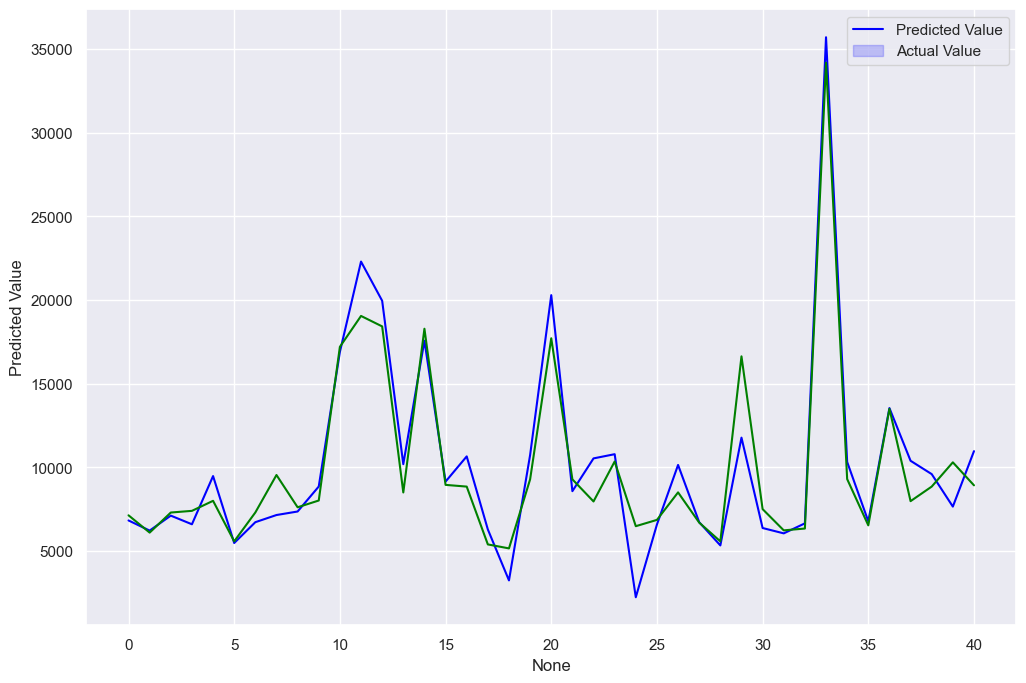

In [57]:
f, ax = plt.subplots(figsize=(12, 8))

sns.lineplot(x=data_actual_pred.index, y='Predicted Value', color='blue', data=data_actual_pred, ax=ax)

sns.lineplot(x=data_actual_pred.index, y='Actual Value', color='green', data=data_actual_pred, ax=ax)

plt.legend(['Predicted Value', 'Actual Value'])